# EDA 04 — What does privacy noise look like? (DAS demonstration data vs. published 2010 Census)

**Question (README, Phase 1 Step 5):** Using DAS demonstration data, how large is disclosure-avoidance (privacy) noise, and how does it behave as geographies shrink — compared with the sampling noise we measured in EDA 01–02?

**Plain-English setup.** Since 2020 the Census Bureau protects respondent privacy by adding deliberate random noise to published Decennial counts — the **Disclosure Avoidance System** (DAS) running the **TopDown Algorithm** (definitions in [`docs/glossary.md`](../docs/glossary.md)). To let the public evaluate that noise, the Bureau ran the 2020 DAS over the confidential 2010 Census data and published the result as **demonstration data**. Because the real 2010 counts were also published (Summary File 1), the difference between the two files is a direct empirical measurement: **noise = demonstration − published**, per geography.

**The hypothesis we test** (flagged as a hypothesis in HANDOFF, not a known fact): sampling noise shrinks like $1/\sqrt{N}$ — log-log slope $-\tfrac{1}{2}$, confirmed for ACS in EDA 02. Privacy noise, if it is a roughly *constant absolute* perturbation per geographic unit, should shrink like $1/N$ — slope $-1$. If that holds, the two dominant noise mechanisms in Census products are measurably different laws, and small places pay the biggest relative price for privacy.

**Two warnings that govern everything below.**
1. **Demonstration data exists only to evaluate privacy noise.** It must never be read as real 2010 populations.
2. **The baseline itself is not noise-free.** Published 2010 SF1 was protected with the older method, record **swapping**. The Bureau's technical document is explicit: *"the comparison is imperfect because some differences between the two sets of data may be a result of swapping."* Everything called "noise" below is DAS noise **plus residual swapping effects**.

**Data.** 2010 DHC Demonstration Data Product, 2022-08-25 release (`python ingestion/pull_das_demo_nj.py`) vs. published 2010 SF1 via the Census API (`python ingestion/pull_sf1_2010_nj.py`) — New Jersey at five levels: state, county, tract, block group, block. Demo-file parser with proven layout: [`analysis/dhc.py`](../analysis/dhc.py).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebook lives in /notebooks; the analysis package lives at the repo root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import dhc

LEVELS = list(dhc.LEVELS)  # state, county, tract, block_group, block
LEVEL_LABELS = {"state": "State", "county": "County", "tract": "Tract",
                "block_group": "Block group", "block": "Block"}
OUT_DIR = REPO_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Prove the parse before trusting a single number

[`analysis/dhc.py`](../analysis/dhc.py) reads the demonstration file straight out of its zip (the raw download is never extracted or altered) and runs a quality panel. The two checks that matter most:

- **The state-population invariant.** The DAS adds *no* noise to state totals, so the demonstration NJ total must equal the published 8,791,894 **exactly**. If the parser read even one field off, hitting that number by accident is essentially impossible — the invariant doubles as a parser-correctness proof.
- **P12B internal additivity.** In tabulated data, total = male + female and each sex = the sum of its 23 age bins, *exactly*, on every record. Any column misalignment shatters these identities.

In [2]:
dhc.quality_panel()

Quality panel -- nj2010.dhc.zip
  PASS  zip has 45 members incl. njgeo2010.dhc (found 45)


  PASS  LOGRECNO unique in geo header
  PASS  state: 1 standard records (expected 1)
  PASS  county: 21 standard records (expected 21)
  PASS  tract: 2,010 standard records (expected 2,010)
  PASS  block_group: 6,320 standard records (expected 6,320)
  PASS  block: 169,588 standard records (expected 169,588)


  PASS  P1 + P12B cells joined 1:1 for all 177,940 records
  PASS  state invariant: demo total 8,791,894 == published 8,791,894
  PASS  P1 equals geo-header POP100 on every record (P1 location proven)


  PASS  P12B additivity holds on all 219,847 records (offsets proven)
  PASS  all extracted cells non-negative
Quality panel: all checks passed.


In [3]:
demo = dhc.demo_counts()  # all five levels, P1 + all 49 P12B cells
# Derived subgroup count: Black alone, 65+ = the same twelve sex x age cells
# used on the ACS side in EDA 02. Counts sum directly (no MOE machinery --
# these are full-count tabulations, not survey estimates).
demo["black65"] = demo[dhc.BLACK_65PLUS_CELLS].sum(axis=1)
demo = demo[["level", "GEOCODE", "NAME", "P001001", "black65"]].rename(columns={"P001001": "pop"})
assert len(demo) == 177_940, f"expected 177,940 records, got {len(demo):,}"
demo.groupby("level").size().rename("records")

level
block          169588
block_group      6320
county             21
state               1
tract            2010
Name: records, dtype: int64

## 2. The published baseline, and a clean join

The baseline is what the Bureau actually published in 2010: Summary File 1 — a full count (no sampling, no margins of error), protected with swapping. We join demonstration to published on the full geographic code and require a **perfect 1:1 match at every level**: a partial join would silently bias every noise statistic that follows.

In [4]:
GEO_PARTS = {"state": ["STATE"], "county": ["STATE", "COUNTY"],
             "tract": ["STATE", "COUNTY", "TRACT"],
             "block_group": ["STATE", "COUNTY", "TRACT", "BLOCK_GROUP"],
             "block": ["STATE", "COUNTY", "TRACT", "BLOCK"]}
GEO_WIDTHS = {"STATE": 2, "COUNTY": 3, "TRACT": 6, "BLOCK_GROUP": 1, "BLOCK": 4}


def load_sf1(level: str) -> pd.DataFrame:
    """One level of the published-SF1 pull, keyed like the demo file's GEOCODE."""
    path = REPO_ROOT / "data" / "raw" / f"sf1_2010_nj_{level}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"{path} -- regenerate with: python ingestion/pull_sf1_2010_nj.py")
    df = pd.read_parquet(path)
    value_cols = [c for c in df.columns if c.startswith("P0")]
    df[value_cols] = df[value_cols].apply(pd.to_numeric)  # raw parquet keeps API strings
    df["GEOCODE"] = ""
    for part in GEO_PARTS[level]:
        df["GEOCODE"] = df["GEOCODE"] + df[part].astype(str).str.zfill(GEO_WIDTHS[part])
    df["black65"] = df[[c for c in value_cols if c.startswith("P012B")]].sum(axis=1)
    df["level"] = level
    return df[["level", "GEOCODE", "P001001", "black65"]].rename(columns={"P001001": "pop"})


sf1 = pd.concat([load_sf1(lv) for lv in LEVELS], ignore_index=True)

m = demo.merge(sf1, on=["level", "GEOCODE"], suffixes=("_demo", "_sf1"),
               how="outer", indicator=True, validate="one_to_one")
assert (m["_merge"] == "both").all(), "demonstration and published geographies must match 1:1"
m = m.drop(columns="_merge")

for var in ("pop", "black65"):
    m[f"err_{var}"] = m[f"{var}_demo"] - m[f"{var}_sf1"]

print(f"Joined {len(m):,} geographies 1:1 across {m['level'].nunique()} levels -- no orphans on either side.")

Joined 177,940 geographies 1:1 across 5 levels -- no orphans on either side.


## 3. What does privacy noise look like?

For every geography, **error = demonstration − published**. Before asking how noise scales, three basic properties: is it centered on zero (noise, not bias)? how big is it at each level? and does it respect the geographic hierarchy?

In [5]:
def noise_summary(var: str) -> pd.DataFrame:
    """Per-level error summary: RMSE is the empirical sigma of the noise."""
    rows = []
    for lv in LEVELS:
        e = m.loc[m["level"] == lv, f"err_{var}"]
        rows.append({"level": LEVEL_LABELS[lv], "n": len(e),
                     "mean error": e.mean(),
                     "RMSE": float(np.sqrt((e ** 2).mean())),
                     "MAE": e.abs().mean(),
                     "% exact": 100 * float((e == 0).mean()),
                     "min": int(e.min()), "max": int(e.max()),
                     "sum": int(e.sum())})
    return pd.DataFrame(rows).set_index("level")


pop_summary = noise_summary("pop")

# The state invariant, seen live in the errors themselves:
assert pop_summary.loc["State", "RMSE"] == 0, "state total must carry zero noise (invariant)"
# Hierarchical consistency: every level still adds up to the invariant state
# total, so each level's errors must cancel to exactly zero -- and they do:
assert (pop_summary["sum"] == 0).all(), "total-population errors should sum to 0 at every level"

pop_summary.round(3)

,n,mean error,RMSE,MAE,% exact,min,max,sum
level,,,,,,,,
State,1,0.0,0.000,0.000,100.000,0,0,0
County,21,0.0,2.268,1.714,28.571,-5,4,0
Tract,2010,0.0,2.496,1.950,17.413,-11,8,0
Block group,6320,0.0,23.215,16.897,3.418,-152,128,0
Block,169588,0.0,6.890,4.265,33.844,-79,49,0


**What the table says.**

- **The noise is mean-zero everywhere** — this is deliberate random noise, not a bias like undercount. And the `sum` column is *exactly* zero at every level: the TopDown Algorithm forces each level to keep adding up to the invariant state total, so every extra person in one place is balanced by a missing person somewhere else.
- **County and tract totals barely move:** RMSE ≈ 2.3 and 2.5 people, on units of tens of thousands to hundreds of thousands of residents. The worst single tract miss in the state is 11 people.
- **Surprise — block groups are the noisiest level in absolute terms:** RMSE 23.2, about **9× the tract level and 3.4× the block level**, with single misses up to ±152 people. Noise does *not* simply grow as geographies shrink; the level itself matters. We characterize this below and log it as a mentor question rather than guessing at the mechanism.
- Blocks: RMSE 6.9, and 34% of blocks come out exactly right.

Chart saved to data\processed\eda04_error_dist_by_level.png (local-only, regenerable)


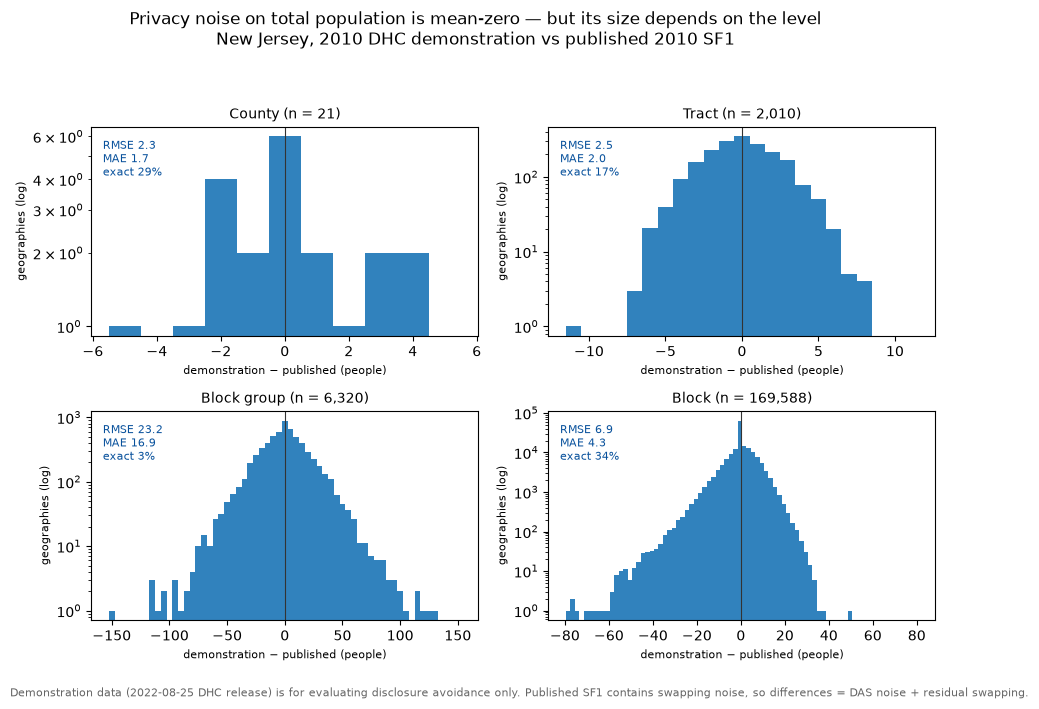

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.8))
for ax, lv in zip(axes.flat, ["county", "tract", "block_group", "block"]):
    e = m.loc[m["level"] == lv, "err_pop"]
    lim = max(abs(int(e.min())), abs(int(e.max())))
    width = max(1, (2 * lim) // 60)
    ax.hist(e, bins=np.arange(-lim - 0.5, lim + width + 0.5, width),
            color="#3182bd", edgecolor="none")
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set_yscale("log")  # keep the rare large misses visible
    ax.set_title(f"{LEVEL_LABELS[lv]} (n = {len(e):,})", fontsize=10)
    ax.text(0.03, 0.94,
            f"RMSE {float(np.sqrt((e ** 2).mean())):.1f}\nMAE {e.abs().mean():.1f}\nexact {100 * (e == 0).mean():.0f}%",
            transform=ax.transAxes, va="top", fontsize=8, color="#08519c")
    ax.set_xlabel("demonstration − published (people)", fontsize=8)
    ax.set_ylabel("geographies (log)", fontsize=8)
fig.suptitle("Privacy noise on total population is mean-zero — but its size depends on the level\n"
             "New Jersey, 2010 DHC demonstration vs published 2010 SF1", fontsize=12)
fig.text(0.01, -0.03,
         "Demonstration data (2022-08-25 DHC release) is for evaluating disclosure avoidance only. "
         "Published SF1 contains swapping noise, so differences = DAS noise + residual swapping.",
         fontsize=8, color="#666666")
fig.tight_layout(rect=(0, 0, 1, 0.94))
out = OUT_DIR / "eda04_error_dist_by_level.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

**Reading the chart.** Each panel is the distribution of errors at one level (log count axis, so the rare big misses stay visible). All four are roughly symmetric bells centered on zero. The x-axis ranges tell the level story at a glance: tract errors live within ±11 people while block-group errors reach ±152 — the non-monotonic pattern from the table, now visible. What these absolute errors *mean* depends entirely on the size of the place they land on — that's the next section.

## 4. Does the noise scale with unit size? (the slope test)

**Method — binned relative RMSE (our methodology, documented here).** EDA 02 fit a per-unit log-log line through CVs. That approach doesn't transfer to privacy noise: the errors are mean-zero integers, and 17–34% of units have error *exactly zero* — a log scale must drop them, which biases any per-unit fit toward the noisier survivors. Instead we bin geographies by published size (quarter-decade log bins, only bins with ≥ 30 units), and compute per bin:

$$\text{relative RMSE} = \frac{\sqrt{\text{mean}\left((\text{demo}-\text{published})^2\right)}}{\text{mean(published)}}$$

RMSE is the empirical sigma of the noise, so this is the direct analog of EDA 02's CV ($\sigma/\text{estimate}$) — the two mechanisms can be read on the same scale. The slope is then fit on the bins with `np.polyfit`, the same convention as EDA 02. Zero-population units have no scale to be relative to and are excluded here — consistent with our standing CV-undefined rule — and get their own accounting in §6.

Because the DAS allocates its **privacy-loss budget** level by level, we fit the slope *within* each level rather than pooling — constant absolute noise within a level would give slope exactly −1.

In [7]:
BIN_WIDTH = 0.25  # quarter-decade log10 bins
MIN_UNITS = 30    # a stable RMSE needs enough units per bin


def binned_rel_rmse(level: str, var: str) -> pd.DataFrame:
    """Relative RMSE by published-size bin, within one geography level."""
    s = m[(m["level"] == level) & (m[f"{var}_sf1"] > 0)].copy()
    s["bin"] = np.floor(np.log10(s[f"{var}_sf1"]) / BIN_WIDTH)
    out = []
    for _, g in s.groupby("bin"):
        if len(g) < MIN_UNITS:
            continue
        rmse = float(np.sqrt((g[f"err_{var}"] ** 2).mean()))
        out.append({"size": g[f"{var}_sf1"].mean(), "rel_rmse": rmse / g[f"{var}_sf1"].mean(),
                    "abs_rmse": rmse, "n_units": len(g)})
    return pd.DataFrame(out)


def loglog_slope(dfb: pd.DataFrame) -> float:
    ok = dfb[dfb["rel_rmse"] > 0]
    return float(np.polyfit(np.log10(ok["size"]), np.log10(ok["rel_rmse"]), 1)[0])


pop_bins = {lv: binned_rel_rmse(lv, "pop") for lv in ("tract", "block_group", "block")}
pop_slopes = {lv: loglog_slope(b) for lv, b in pop_bins.items()}

print("Fitted log-log slopes, total population")
print("(constant absolute noise would be -1.00; pure sampling noise is -0.50):")
for lv, s in pop_slopes.items():
    print(f"  {LEVEL_LABELS[lv]:<12} {s:+.2f}   ({len(pop_bins[lv])} bins)")

# County: 21 units is too few to bin -- one pooled point for the chart.
cty = m[m["level"] == "county"]
county_point = {"size": cty["pop_sf1"].mean(),
                "rel_rmse": float(np.sqrt((cty["err_pop"] ** 2).mean())) / cty["pop_sf1"].mean()}
print(f"  County       one pooled point: relative RMSE {county_point['rel_rmse']:.1e} "
      f"at mean size {county_point['size']:,.0f}")

# Same-size, different-level gap (the block-group anomaly, quantified):
bg, tr = pop_bins["block_group"], pop_bins["tract"]
bg_at = bg.loc[(bg["size"] - 1400).abs().idxmin()]
tr_at = tr.loc[(tr["size"] - 1400).abs().idxmin()]
bg_tract_gap = bg_at["rel_rmse"] / tr_at["rel_rmse"]
print(f"\nAt ~1,400 residents: block-group relative noise {bg_at['rel_rmse']:.4f} vs "
      f"tract {tr_at['rel_rmse']:.4f} -- a {bg_tract_gap:.0f}x gap at the same size.")

# Guard the claims.
for lv, s in pop_slopes.items():
    assert -1.05 < s < -0.70, f"{lv} slope {s:+.2f} outside the near-1/N range"
    assert s < -0.60, f"{lv} slope {s:+.2f} not clearly steeper than sampling's -0.50"
assert bg_tract_gap > 5, "block groups should be several times noisier than same-size tracts"
# Honesty check on 'constant absolute noise': within blocks it is NOT perfectly
# constant -- absolute RMSE grows several-fold from the smallest to largest bins
# (which is exactly why the slopes land shallower than the ideal -1):
assert pop_bins["block"]["abs_rmse"].iloc[-1] > 3 * pop_bins["block"]["abs_rmse"].iloc[0]

pop_bins["block"].round(4)

Fitted log-log slopes, total population
(constant absolute noise would be -1.00; pure sampling noise is -0.50):
  Tract        -0.90   (4 bins)
  Block group  -0.85   (5 bins)
  Block        -0.78   (14 bins)
  County       one pooled point: relative RMSE 5.4e-06 at mean size 418,662

At ~1,400 residents: block-group relative noise 0.0175 vs tract 0.0015 -- a 12x gap at the same size.


,size,rel_rmse,abs_rmse,n_units
0,1.0000,7.1906,7.1906,1294
1,2.4335,2.8970,7.0499,3788
2,4.4493,1.4770,6.5716,3334
3,7.4606,0.8518,6.3553,5534
4,13.4914,0.4651,6.2755,10506
5,24.6024,0.2576,6.3378,19151
6,43.0803,0.1591,6.8525,27621
7,74.5978,0.1039,7.7523,23657
8,130.4605,0.0729,9.5146,13495
9,231.2263,0.0518,11.9778,6779


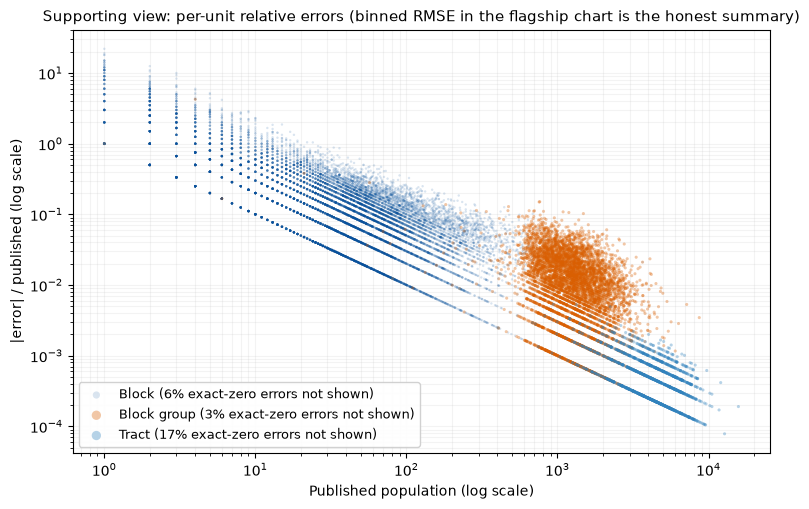

In [8]:
# Supporting view: every unit, not bins. Exact-zero errors cannot appear on a
# log axis -- their share is reported here so the exclusion is explicit.
fig, ax = plt.subplots(figsize=(9, 5.5))
styles = {"block": ("#08519c", 3, 0.15), "block_group": ("#d95f02", 5, 0.35),
          "tract": ("#3182bd", 5, 0.35)}
for lv, (color, size, alpha) in styles.items():
    s = m[(m["level"] == lv) & (m["pop_sf1"] > 0)]
    excl = 100 * float((s["err_pop"] == 0).mean())
    nz = s[s["err_pop"] != 0]
    if len(nz) > 15_000:
        nz = nz.sample(15_000, random_state=42)  # keep the PNG light; deterministic
    ax.scatter(nz["pop_sf1"], nz["err_pop"].abs() / nz["pop_sf1"], s=size, color=color,
               alpha=alpha, edgecolors="none",
               label=f"{LEVEL_LABELS[lv]} ({excl:.0f}% exact-zero errors not shown)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_axisbelow(True)
ax.grid(which="both", alpha=0.15)
ax.legend(loc="lower left", fontsize=9, markerscale=3, framealpha=0.9)
ax.set_xlabel("Published population (log scale)")
ax.set_ylabel("|error| / published (log scale)")
ax.set_title("Supporting view: per-unit relative errors (binned RMSE in the flagship chart is the honest summary)",
             fontsize=11)
plt.show()

## 5. The flagship chart — two noise laws on one axis

Everything above collapses into one picture: relative noise vs. unit size, per level, with the two theoretical guide lines. If privacy noise is (nearly) a constant absolute cost, its series should run parallel to the slope −1 guide — visibly steeper than the slope −½ sampling law that governs the ACS (EDA 02).

Chart saved to data\processed\eda04_noise_rmse_by_size.png (local-only, regenerable)


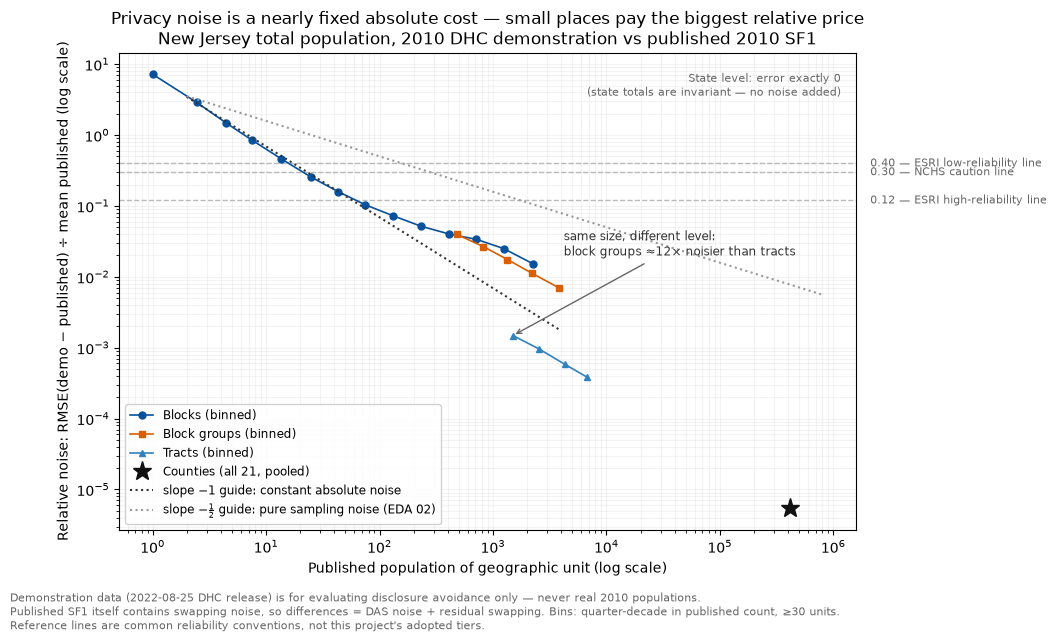

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))

series = [("block", "Blocks (binned)", "o", "#08519c"),
          ("block_group", "Block groups (binned)", "s", "#d95f02"),
          ("tract", "Tracts (binned)", "^", "#3182bd")]
for lv, label, marker, color in series:
    b = pop_bins[lv]
    ax.plot(b["size"], b["rel_rmse"], marker=marker, color=color,
            linewidth=1.2, markersize=5, label=label)
ax.plot(county_point["size"], county_point["rel_rmse"], marker="*", linestyle="none",
        color="#111111", markersize=14, label="Counties (all 21, pooled)")

guide = np.logspace(0.3, 3.6, 40)
ax.plot(guide, 6.9 / guide, linestyle=":", color="#333333", linewidth=1.5,
        label=r"slope $-1$ guide: constant absolute noise")
guide2 = np.logspace(0.3, 5.9, 40)
ax.plot(guide2, 5.0 / np.sqrt(guide2), linestyle=":", color="#999999", linewidth=1.5,
        label=r"slope $-\frac{1}{2}$ guide: pure sampling noise (EDA 02)")

for y, label in [(0.12, "0.12 — ESRI high-reliability line"),
                 (0.30, "0.30 — NCHS caution line"),
                 (0.40, "0.40 — ESRI low-reliability line")]:
    ax.axhline(y, color="#bbbbbb", linestyle="--", linewidth=1, zorder=0)
    ax.text(1.02, y, label, transform=ax.get_yaxis_transform(),
            fontsize=8, va="center", color="#666666")

ax.annotate("same size, different level:\nblock groups ≈12× noisier than tracts",
            xy=(float(tr_at["size"]), float(tr_at["rel_rmse"])), xytext=(4200, 0.02),
            arrowprops=dict(arrowstyle="->", color="#666666"),
            fontsize=8.5, color="#333333")
ax.text(0.98, 0.96, "State level: error exactly 0\n(state totals are invariant — no noise added)",
        transform=ax.transAxes, fontsize=8, color="#666666", ha="right", va="top")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_axisbelow(True)
ax.grid(which="both", alpha=0.15)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.set_xlabel("Published population of geographic unit (log scale)")
ax.set_ylabel("Relative noise: RMSE(demo − published) ÷ mean published (log scale)")
ax.set_title("Privacy noise is a nearly fixed absolute cost — small places pay the biggest relative price\n"
             "New Jersey total population, 2010 DHC demonstration vs published 2010 SF1", fontsize=12)
fig.text(0.01, -0.05,
         "Demonstration data (2022-08-25 DHC release) is for evaluating disclosure avoidance only — never real 2010 populations.\n"
         "Published SF1 itself contains swapping noise, so differences = DAS noise + residual swapping. "
         "Bins: quarter-decade in published count, ≥30 units.\n"
         "Reference lines are common reliability conventions, not this project's adopted tiers.",
         fontsize=8, color="#666666")

out = OUT_DIR / "eda04_noise_rmse_by_size.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

**Reading the chart.** Two findings, one per pattern:

1. **The slope test: privacy noise behaves like a (nearly) fixed absolute cost.** Within-level slopes are −0.78 (block), −0.85 (block group), −0.90 (tract) — all far steeper than the −½ sampling law and close to the −1 constant-noise ideal. The hypothesis is **directionally confirmed with an honest caveat**: absolute noise is not perfectly constant within a level (block RMSE grows from ≈6.3 in the smallest bins to ≈34 in the largest — visible as the series running slightly shallower than the −1 guide). The practical reading: for **total population**, privacy noise crosses the 0.30 caution line only for blocks of ≈21 people and the 0.12 line at ≈62; at tract and county scale it is negligible (relative noise ≤ 0.2%).

2. **The block-group anomaly: level matters, not just size.** A ~1,400-person block group carries ≈12× the relative noise of a ~1,400-person tract. Noise is set by *where the DAS spends its privacy-loss budget*, not by unit size alone. A consistent mechanism — offered as a **hypothesis, not a conclusion**: DAS documentation describes allocating budget down a spine of geographic levels, and if this release's tabulation block groups are assembled *off* that spine by summing noisy blocks, their errors should accumulate like $\sqrt{\text{blocks per BG}}$: with ≈18.8 occupied blocks per NJ block group, $\sqrt{18.8} \times 6.9 \approx 30$ — the right order for the observed 23 (some cancellation expected). **Logged as a mentor question** (README) rather than asserted.

Composite-score implication (Q2): for Decennial products, a reliability score needs the **geography level itself** as a component — the same-size-different-noise gap cannot be captured by population size alone.

## 6. Ghost and vanished places

Mean-zero noise on small counts produces a *categorical* artifact that deserves its own accounting rather than being folded into averages (the same principle as our CV-undefined rule): places published as empty that the demonstration shows as populated ("ghosts"), and the reverse ("vanished").

In [10]:
blk = m[m["level"] == "block"]
zero_sf1 = blk["pop_sf1"] == 0
ghosts = blk[zero_sf1 & (blk["pop_demo"] > 0)]
vanished = blk[(blk["pop_sf1"] > 0) & (blk["pop_demo"] == 0)]

print(f"Blocks published as zero-population: {int(zero_sf1.sum()):,} "
      f"({100 * float(zero_sf1.mean()):.0f}% of all NJ blocks)")
print(f"Ghost blocks (published 0 -> demo > 0):    {len(ghosts):,} "
      f"| {int(ghosts['pop_demo'].sum()):,} phantom people "
      f"(median {ghosts['pop_demo'].median():.0f}/block, max {int(ghosts['pop_demo'].max())})")
print(f"Vanished blocks (published > 0 -> demo 0): {len(vanished):,} "
      f"| {int(vanished['pop_sf1'].sum()):,} people erased "
      f"(median {vanished['pop_sf1'].median():.0f}/block, max {int(vanished['pop_sf1'].max())})")

assert len(ghosts) == 807 and len(vanished) == 427, "ghost/vanished counts changed -- re-examine"
# Above block level, total population never ghosts or vanishes in this file:
for lv in ("tract", "block_group"):
    s = m[m["level"] == lv]
    assert not ((s["pop_sf1"] == 0) & (s["pop_demo"] > 0)).any(), f"unexpected ghost {lv}"
    assert not ((s["pop_sf1"] > 0) & (s["pop_demo"] == 0)).any(), f"unexpected vanished {lv}"
print("Tracts and block groups: no ghosts, no vanished (zero-population units stayed zero).")

# Near-empty tracts: absolute noise of +-1 person is enormous in relative terms.
near_empty = m[(m["level"] == "tract") & (m["pop_sf1"].between(1, 100))]
near_empty[["GEOCODE", "NAME", "pop_sf1", "pop_demo", "err_pop"]]

Blocks published as zero-population: 50,934 (30% of all NJ blocks)
Ghost blocks (published 0 -> demo > 0):    807 | 4,695 phantom people (median 4/block, max 28)
Vanished blocks (published > 0 -> demo 0): 427 | 1,154 people erased (median 2/block, max 11)
Tracts and block groups: no ghosts, no vanished (zero-population units stayed zero).


,GEOCODE,NAME,pop_sf1,pop_demo,err_pop
176817,34017006900,Census Tract 69,81,80,-1
177250,34025804700,Census Tract 8047,16,17,1
177572,34029980000,Census Tract 9800,5,5,0
177573,34029980100,Census Tract 9801,1,2,1


**Why this matters.** For uses that consume block-level counts directly — redistricting, emergency planning, siting decisions — a ghost or vanished block is not "a little noise": it flips a place between *inhabited* and *empty*. 807 ghost blocks carry 4,695 phantom residents; 427 vanished blocks erase 1,154 real ones. And at near-empty places relative error is unbounded — Ocean County's 1-person tract 9801 shows as 2 people in the demonstration: a +100% error from ±1 person of noise. Any reliability score must treat zero/near-zero baselines as their own class (this is exactly the project's standing CV-undefined decision, now justified for a second mechanism).

## 7. The small-subgroup parallel: Black alone, 65+

EDA 02's headline was that small subgroup counts are the reliability weak point of the ACS. Here is the same subgroup — the same twelve sex×age cells, summed — under privacy noise instead of sampling noise. One structural difference to notice up front: **only *total* population is invariant.** Characteristic tables like P12B get noise even at the state level.

In [11]:
b65_summary = noise_summary("black65")

state_pub = int(m.loc[m["level"] == "state", "black65_sf1"].iloc[0])
state_err = int(m.loc[m["level"] == "state", "err_black65"].iloc[0])
print(f"Statewide Black 65+: published {state_pub:,}, demonstration {state_pub + state_err:,} "
      f"(error {state_err:+d} -- characteristic tables are NOT invariant)")
assert state_err != 0, "P12B should carry noise even at state level"
# The statewide error propagates exactly: the P12B table stays hierarchically
# consistent, so every level's errors sum to the same statewide error.
assert (b65_summary["sum"] == state_err).all()

blk65 = m[m["level"] == "block"]
print(f"Blocks with zero published Black 65+: {100 * float((blk65['black65_sf1'] == 0).mean()):.0f}% -- "
      f"ghosts {int(((blk65['black65_sf1'] == 0) & (blk65['black65_demo'] > 0)).sum()):,}, "
      f"vanished {int(((blk65['black65_sf1'] > 0) & (blk65['black65_demo'] == 0)).sum()):,}")

b65_summary.round(3)

Statewide Black 65+: published 116,367, demonstration 116,383 (error +16 -- characteristic tables are NOT invariant)
Blocks with zero published Black 65+: 85% -- ghosts 9,987, vanished 10,433


,n,mean error,RMSE,MAE,% exact,min,max,sum
level,,,,,,,,
State,1,16.000,16.000,16.000,0.000,16,16,16
County,21,0.762,34.615,29.810,4.762,-63,55,16
Tract,2010,0.008,7.063,5.133,9.353,-32,26,16
Block group,6320,0.003,6.853,4.065,16.772,-68,63,16
Block,169588,0.000,1.644,0.489,81.018,-40,36,16


Fitted log-log slopes, Black alone 65+:
  Tract        -0.78   (11 bins)
  Block group  -0.57   (10 bins)
  Block        -0.55   (9 bins)
  County       one pooled point: relative RMSE 0.0062 at mean size 5,541

Median NJ tract holds 18 Black 65+ residents.


Chart saved to data\processed\eda04_black65_rmse_by_size.png (local-only, regenerable)


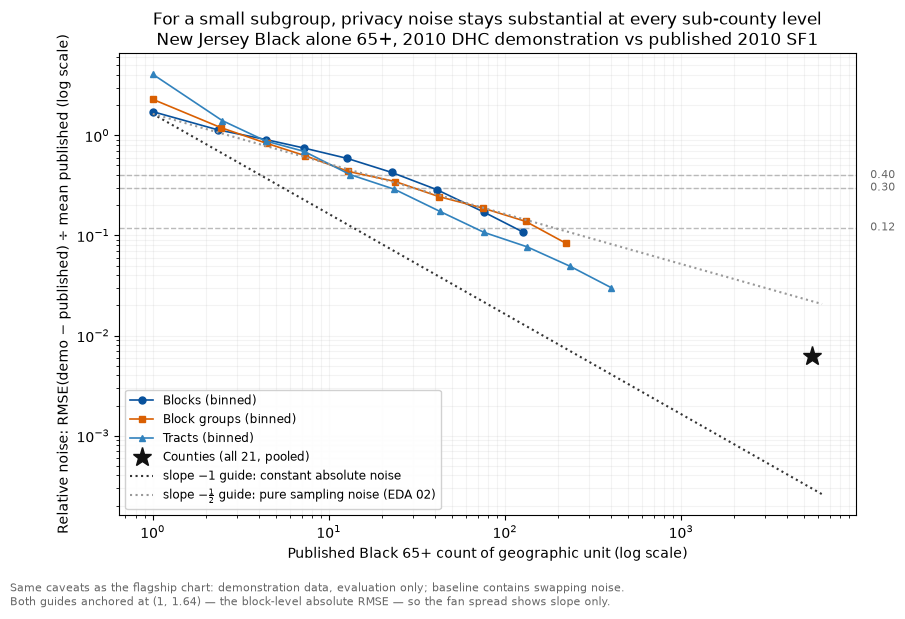

In [12]:
b65_bins = {lv: binned_rel_rmse(lv, "black65") for lv in ("tract", "block_group", "block")}
b65_slopes = {lv: loglog_slope(b) for lv, b in b65_bins.items()}
cty65 = m[m["level"] == "county"]
county_point65 = {"size": cty65["black65_sf1"].mean(),
                  "rel_rmse": float(np.sqrt((cty65["err_black65"] ** 2).mean())) / cty65["black65_sf1"].mean()}

print("Fitted log-log slopes, Black alone 65+:")
for lv, s in b65_slopes.items():
    print(f"  {LEVEL_LABELS[lv]:<12} {s:+.2f}   ({len(b65_bins[lv])} bins)")
print(f"  County       one pooled point: relative RMSE {county_point65['rel_rmse']:.4f} "
      f"at mean size {county_point65['size']:,.0f}")

med_tract = m.loc[m["level"] == "tract", "black65_sf1"].median()
print(f"\nMedian NJ tract holds {med_tract:.0f} Black 65+ residents.")

# Guard the claims.
small_tract = b65_bins["tract"][b65_bins["tract"]["size"] <= 20]
assert (small_tract["rel_rmse"] >= 0.29).all(), "subgroup noise at <=20-person tract counts should sit at/above the caution line"
for lv in b65_slopes:  # shallower than total population at every level
    assert b65_slopes[lv] > pop_slopes[lv], f"{lv}: subgroup slope should be shallower (non-negativity truncates noise on tiny counts)"

fig, ax = plt.subplots(figsize=(9.5, 6))
for lv, label, marker, color in series:  # same styling as the flagship chart
    b = b65_bins[lv]
    ax.plot(b["size"], b["rel_rmse"], marker=marker, color=color,
            linewidth=1.2, markersize=5, label=label)
ax.plot(county_point65["size"], county_point65["rel_rmse"], marker="*", linestyle="none",
        color="#111111", markersize=14, label="Counties (all 21, pooled)")
guide = np.logspace(0, 3.8, 40)
ax.plot(guide, 1.64 / guide, linestyle=":", color="#333333", linewidth=1.5,
        label=r"slope $-1$ guide: constant absolute noise")
ax.plot(guide, 1.64 / np.sqrt(guide), linestyle=":", color="#999999", linewidth=1.5,
        label=r"slope $-\frac{1}{2}$ guide: pure sampling noise (EDA 02)")
for y, label in [(0.12, "0.12"), (0.30, "0.30"), (0.40, "0.40")]:
    ax.axhline(y, color="#bbbbbb", linestyle="--", linewidth=1, zorder=0)
    ax.text(1.02, y, label, transform=ax.get_yaxis_transform(),
            fontsize=8, va="center", color="#666666")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_axisbelow(True)
ax.grid(which="both", alpha=0.15)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.set_xlabel("Published Black 65+ count of geographic unit (log scale)")
ax.set_ylabel("Relative noise: RMSE(demo − published) ÷ mean published (log scale)")
ax.set_title("For a small subgroup, privacy noise stays substantial at every sub-county level\n"
             "New Jersey Black alone 65+, 2010 DHC demonstration vs published 2010 SF1", fontsize=12)
fig.text(0.01, -0.04,
         "Same caveats as the flagship chart: demonstration data, evaluation only; baseline contains swapping noise.\n"
         "Both guides anchored at (1, 1.64) — the block-level absolute RMSE — so the fan spread shows slope only.",
         fontsize=8, color="#666666")
out = OUT_DIR / "eda04_black65_rmse_by_size.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

**Reading the chart — and the mechanism comparison this project exists to make.**

- The subgroup's relative noise is substantial everywhere below county level: at the **median tract count (18 people), relative noise is ≈0.3–0.4** — at or above the NCHS caution line. At block level, single-person cells carry ≈170% relative noise.
- Slopes are **shallower** than for total population (−0.55 to −0.78 vs −0.78 to −0.90). This is the non-negativity constraint at work: a 1-person cell can't lose more than 1 person, so noise on tiny counts is truncated — relative noise at the smallest sizes is capped below what the −1 law would predict. (Also visible: 81% of block-level cells come out exactly right, mostly zeros staying zero.)
- Absolute noise by level is again non-monotonic and *table-dependent*: for P12B, county RMSE (34.6) exceeds tract (7.1) and block group (6.9) — a different level pattern than total population showed. More budget-allocation structure to ask the mentors about.

**Sampling vs. privacy, one subgroup, tract level.** EDA 02 measured the ACS sampling noise on this same subgroup at a median CV of **0.886**; the demonstration data puts privacy noise at the same typical counts at **≈0.3–0.4**. Same order of magnitude — for small subgroups, privacy noise is *not* negligible next to sampling noise, though sampling remains ~2–3× larger at tract scale. At block level the comparison inverts by construction: the ACS doesn't publish there at all. **Caveats:** different vintages (2010 Census vs 2020–2024 ACS), different universes and products — this is a comparison of *mechanisms*, never a decomposition of any single published number.

## Findings

**What did we find?**

1. **Privacy noise is mean-zero and hierarchically disciplined.** Total-population errors sum to exactly zero at every level (the state invariant propagating down); the subgroup's statewide error (+16) propagates identically. Noise, not bias.
2. **The slope test (the hypothesis this notebook existed to run): directionally confirmed.** Within-level slopes for total population are −0.78 to −0.90 — clearly steeper than the sampling law's −½ (EDA 02) and close to the constant-absolute-noise ideal of −1, with the honest caveat that absolute noise grows several-fold across a level's size range, so the ideal −1 is not exact. **The two dominant noise mechanisms in Census products follow measurably different laws.**
3. **The block-group anomaly (surprise).** Absolute noise by level is non-monotonic: block groups (RMSE 23.2) are ≈9× noisier than tracts (2.5) and ≈3.4× noisier than blocks (6.9); a same-size block group carries ≈12× a tract's relative noise. For the subgroup table the level pattern differs again (county noisiest in absolute terms). Level — where the privacy-loss budget is spent — is a first-class reliability factor. *Mechanism hypothesis logged as a mentor question, not asserted.*
4. **Practical thresholds (descriptive conventions, not adopted tiers):** for total population, privacy noise crosses the 0.30 caution line only below ≈21-person blocks and the 0.12 line below ≈62; tract- and county-level totals are essentially untouched (≤0.2%). For the Black 65+ subgroup, the median tract (18 people) already sits at ≈0.3–0.4 relative noise.
5. **Ghost and vanished places are a categorical artifact class:** 807 blocks gain phantom residents (4,695 people), 427 lose all of theirs (1,154). Zero/near-zero baselines need their own reporting class — the same rule we adopted for undefined CVs, now justified under a second mechanism.

**Why it matters to the Census Bureau.** Fitness-for-use guidance can now be *mechanism-aware*: sampling noise is a roughly proportional cost that improves with $\sqrt{N}$; privacy noise is a roughly fixed absolute cost per unit that all but vanishes for large areas and dominates small ones. Those imply different user advice (aggregate geographies to escape privacy noise; aggregate *variables/years* to tame sampling noise) — and different composite-score components (Q2): unit size, geography level, variable type (total vs. characteristic), and product mechanism.

**What should we do next?**
- Take the flagship chart and the block-group anomaly to the July 22 biweekly; ask the mentors: what allocation produced the block-group and county-level patterns, and is the off-spine aggregation reading right? (Logged in README.)
- EDA #5: allocation rates — the third mechanism (imputation), and the test of whether composite-score components are actually independent.
- If the privacy-loss-budget numbers become score-relevant, pull the release's allocation file (not in our current download; noted in the data dictionary).

*Charts saved: `eda04_error_dist_by_level.png`, `eda04_noise_rmse_by_size.png`, `eda04_black65_rmse_by_size.png` (all local-only, regenerable by this notebook).*